<a href="https://colab.research.google.com/github/Srivani-Govindu/Attention-Guided-Quantum-LSTM-with-RDO-for-Aspect-Oriented-Sentiment-Classification/blob/main/alsa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# =========================================================
# STEP 1: IMPORT LIBRARIES
# =========================================================
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import re
import numpy as np

from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
from sklearn.utils.class_weight import compute_class_weight

In [ ]:
df = pd.read_csv('/content/app_reviews.csv')
df.head()[['content','score']]

,content,score
0,I cannot open the app anymore,1
1,I have been begging for a refund from this app...,1
2,Very costly for the premium version (approx In...,1
3,"Used to keep me organized, but all the 2020 UP...",1
4,Dan Birthday Oct 28,1


In [ ]:
df = df[['content', 'score']]
df.dropna(inplace=True)

def score_to_sentiment(score):
    if score >= 4:
        return 1   # Positive
    elif score <= 2:
        return 0   # Negative
    else:
        return None  # Neutral

df['sentiment'] = df['score'].apply(score_to_sentiment)
df.dropna(inplace=True)
df['sentiment'] = df['sentiment'].astype(int)
df.head()

,content,score,sentiment
0,I cannot open the app anymore,1,0
1,I have been begging for a refund from this app...,1,0
2,Very costly for the premium version (approx In...,1,0
3,"Used to keep me organized, but all the 2020 UP...",1,0
4,Dan Birthday Oct 28,1,0


In [ ]:
df.tail()

,content,score,sentiment
12490,"I really like the planner, it helps me achieve...",5,1
12491,😁****😁,5,1
12492,Very useful apps. You must try it,5,1
12493,Would pay for this if there were even more add...,5,1
12494,Sooow good,5,1


In [ ]:
# NLP
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return ' '.join(words)

df['cleaned_content'] = df['content'].apply(clean_text)
df.head()

,content,score,sentiment,cleaned_content
0,I cannot open the app anymore,1,0,cannot open app anymore
1,I have been begging for a refund from this app...,1,0,begging refund app month nobody replying
2,Very costly for the premium version (approx In...,1,0,costly premium version approx indian rupees pe...
3,"Used to keep me organized, but all the 2020 UP...",1,0,used keep organized updates made mess things c...
4,Dan Birthday Oct 28,1,0,dan birthday oct


In [ ]:
## BASELINE MODEL LSTM

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

X = df['cleaned_content']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

max_words = 10000
max_len = 100

tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len)

model = Sequential()

model.add(Embedding(input_dim=max_words, output_dim=128))
model.add(LSTM(128, return_sequences=False))
model.add(Dropout(0.3))
model.add(Dense(1, activation='sigmoid'))

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train_pad,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1
)
# Predict probabilities
y_pred_prob = model.predict(X_test_pad)

# Convert probabilities to class labels (0 or 1)
y_pred = (y_pred_prob > 0.5).astype(int).reshape(-1)

# Evaluation
print("Standard LSTM Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Epoch 1/12
119/119 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.6490 - loss: 0.6249 - val_accuracy: 0.8347 - val_loss: 0.3892
Epoch 2/12
119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8793 - loss: 0.3194 - val_accuracy: 0.8490 - val_loss: 0.3626
Epoch 3/12
119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9203 - loss: 0.2197 - val_accuracy: 0.8442 - val_loss: 0.3977
Epoch 4/12
119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9423 - loss: 0.1666 - val_accuracy: 0.8442 - val_loss: 0.4077
Epoch 5/12
119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9568 - loss: 0.1279 - val_accuracy: 0.8395 - val_loss: 0.4356
Epoch 6/12
119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9675 - loss: 0.1055 - val_accuracy: 0.8359 - val_loss: 0.4917
Epoch 7/12
119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9688 - loss: 0.0904 - val_accuracy: 0.8323 - val_loss: 0.5411
Epoch 8/12
119/119 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9685 - loss: 0.0908 - val_accuracy

In [ ]:
###QLSTM

from tensorflow.keras.layers import Layer
import tensorflow as tf

class QuantumInspiredEmbedding(Layer):
    def __init__(self, vocab_size, embed_dim):
        super(QuantumInspiredEmbedding, self).__init__()
        self.embed_dim = embed_dim
        self.real_embedding = tf.keras.layers.Embedding(vocab_size, embed_dim)
        self.imag_embedding = tf.keras.layers.Embedding(vocab_size, embed_dim)

    def call(self, inputs):
        real_part = self.real_embedding(inputs)
        imag_part = self.imag_embedding(inputs)

        # Quantum-inspired magnitude and phase fusion
        magnitude = tf.sqrt(tf.square(real_part) + tf.square(imag_part))
        phase = tf.math.atan2(imag_part, real_part)

        # Concatenate magnitude & phase
        return tf.concat([magnitude, phase], axis=-1)

###tuned qlstm
qlstm_model = Sequential()

qlstm_model.add(
    QuantumInspiredEmbedding(
        vocab_size=max_words,
        embed_dim=64
    )
)
qlstm_model.add(
    LSTM(
        128,
        return_sequences=False
    )
)
qlstm_model.add(Dropout(0.5))
qlstm_model.add(Dense(1, activation='sigmoid'))

from tensorflow.keras.optimizers import Adam

qlstm_model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_qlstm = qlstm_model.fit(
    X_train_pad,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
)

y_pred_qlstm = (qlstm_model.predict(X_test_pad) > 0.5).astype("int32")

qlstm_acc = accuracy_score(y_test, y_pred_qlstm)

print("Final QLSTM Accuracy:", qlstm_acc)
print(classification_report(y_test, y_pred_qlstm))

qlstm_acc = accuracy_score(y_test, y_pred_qlstm)

print("Quantum-Inspired LSTM Accuracy:", qlstm_acc)

Epoch 1/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.5796 - loss: 0.6724 - val_accuracy: 0.6528 - val_loss: 0.6201
Epoch 2/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6604 - loss: 0.6083 - val_accuracy: 0.6825 - val_loss: 0.5862
Epoch 3/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6869 - loss: 0.5916 - val_accuracy: 0.6885 - val_loss: 0.5925
Epoch 4/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7202 - loss: 0.5639 - val_accuracy: 0.7075 - val_loss: 0.5758
Epoch 5/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7336 - loss: 0.5398 - val_accuracy: 0.7503 - val_loss: 0.5225
Epoch 6/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7893 - loss: 0.4623 - val_accuracy: 0.7646 - val_loss: 0.4782
Epoch 7/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7598 - loss: 0.4998 - val_accuracy: 0.7907 - val_loss: 0.4689
Epoch 8/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8374 - loss: 0.3852 - val_accu

In [ ]:
##RDO
import random
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

def fitness_function(lstm_units, dropout_rate, learning_rate):

    model = Sequential()
    model.add(QuantumInspiredEmbedding(max_words, 64))
    model.add(LSTM(lstm_units))
    model.add(Dropout(dropout_rate))
    model.add(Dense(1, activation='sigmoid'))

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=0,              # VERY aggressive
        restore_best_weights=True
    )

    history = model.fit(
        X_train_pad,
        y_train,
        epochs=3,
        batch_size=128,
        validation_split=0.05,
        callbacks=[early_stop],
        verbose=0
    )

    return -min(history.history['val_loss'])

population_size = 6
red_deer_population = []

for _ in range(population_size):
    deer = {
        "units": random.choice([64, 128]),     # removed 256 (too heavy)
        "dropout": round(random.uniform(0.35, 0.55), 2),
        "lr": random.choice([0.001, 0.0005])
    }
    red_deer_population.append(deer)

print("Initial Red Deer Population:")
for d in red_deer_population:
    print(d)

iterations = 3
best_deer = None
best_fitness = float("-inf")

for iteration in range(iterations):
    print(f"\nIteration {iteration + 1}")

    for deer in red_deer_population:
        fitness = fitness_function(
            deer["units"],
            deer["dropout"],
            deer["lr"]
        )

        print("Deer:", deer, "| Fitness (−val_loss):", fitness)

        if fitness > best_fitness:
            best_fitness = fitness
            best_deer = deer.copy()

print("\n✅ Best QLSTM Parameters Found by RDO")
print(best_deer)
print("Best Fitness Score:", best_fitness)

Initial Red Deer Population:
{'units': 128, 'dropout': 0.4, 'lr': 0.0005}
{'units': 64, 'dropout': 0.43, 'lr': 0.001}
{'units': 64, 'dropout': 0.37, 'lr': 0.0005}
{'units': 64, 'dropout': 0.46, 'lr': 0.001}
{'units': 128, 'dropout': 0.4, 'lr': 0.0005}
{'units': 128, 'dropout': 0.51, 'lr': 0.0005}

Iteration 1
Deer: {'units': 128, 'dropout': 0.4, 'lr': 0.0005} | Fitness (−val_loss): -0.6127116084098816
Deer: {'units': 64, 'dropout': 0.43, 'lr': 0.001} | Fitness (−val_loss): -0.6106579899787903
Deer: {'units': 64, 'dropout': 0.37, 'lr': 0.0005} | Fitness (−val_loss): -0.6184223294258118
Deer: {'units': 64, 'dropout': 0.46, 'lr': 0.001} | Fitness (−val_loss): -0.6215755939483643
Deer: {'units': 128, 'dropout': 0.4, 'lr': 0.0005} | Fitness (−val_loss): -0.5678735971450806
Deer: {'units': 128, 'dropout': 0.51, 'lr': 0.0005} | Fitness (−val_loss): -0.6089490056037903

Iteration 2
Deer: {'units': 128, 'dropout': 0.4, 'lr': 0.0005} | Fitness (−val_loss): -0.6016779541969299
Deer: {'units': 64,

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

final_model = Sequential()
final_model.add(QuantumInspiredEmbedding(max_words, 64))
final_model.add(LSTM(best_deer["units"]))
final_model.add(Dropout(best_deer["dropout"]))
final_model.add(Dense(1, activation='sigmoid'))

final_model.compile(
    optimizer=Adam(learning_rate=best_deer["lr"]),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

history_rdo= final_model.fit(
    X_train_pad,
    y_train,
    epochs=15,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

y_pred_rdo = (final_model.predict(X_test_pad) > 0.5).astype("int32")

from sklearn.metrics import accuracy_score, classification_report

rdo_acc = accuracy_score(y_test, y_pred_rdo)

print("\n📌 FINAL RESULTS")
print("QLSTM + RDO Accuracy:", rdo_acc)
print(classification_report(y_test, y_pred_rdo))

Epoch 1/15
119/119 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.6027 - loss: 0.6600 - val_accuracy: 0.6540 - val_loss: 0.6275
Epoch 2/15
119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6943 - loss: 0.5850 - val_accuracy: 0.6457 - val_loss: 0.6270
Epoch 3/15
119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6897 - loss: 0.5883 - val_accuracy: 0.6742 - val_loss: 0.6108
Epoch 4/15
119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7111 - loss: 0.5573 - val_accuracy: 0.7325 - val_loss: 0.5513
Epoch 5/15
119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7519 - loss: 0.5078 - val_accuracy: 0.6207 - val_loss: 0.6743
Epoch 6/15
119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7252 - loss: 0.5510 - val_accuracy: 0.7765 - val_loss: 0.5200
Epoch 7/15
119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8015 - loss: 0.4422 - val_accuracy: 0.8121 - val_loss: 0.4274
Epoch 8/15
119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8541 - loss: 0.3543 - val_accu

In [ ]:
from tensorflow.keras.layers import Bidirectional, GlobalAveragePooling1D, Concatenate, SpatialDropout1D, Layer, BatchNormalization
import tensorflow as tf

class AttentionLayer(Layer):
    def __init__(self, **kwargs):
        super(AttentionLayer, self).__init__(**kwargs)

    def build(self, input_shape):
        self.W = self.add_weight(name="att_weight", shape=(input_shape[-1], input_shape[-1]),
                                 initializer="glorot_uniform", trainable=True)
        self.b = self.add_weight(name="att_bias", shape=(input_shape[-1],),
                                 initializer="zeros", trainable=True)
        self.u = self.add_weight(name="att_u", shape=(input_shape[-1],),
                                 initializer="glorot_uniform", trainable=True)
        super(AttentionLayer, self).build(input_shape)

    def call(self, x):
        uit = tf.tanh(tf.matmul(x, self.W) + self.b)
        ait = tf.tensordot(uit, self.u, axes=1)
        a = tf.nn.softmax(ait)
        output = tf.reduce_sum(x * tf.expand_dims(a, -1), axis=1)
        return output

def build_final_model():
    inputs = tf.keras.Input(shape=(max_len,))

    # Quantum-Inspired Embedding
    x = QuantumInspiredEmbedding(max_words, 100)(inputs)
    x = SpatialDropout1D(0.3)(x)

    # Bidirectional LSTM to capture context from both sides
    lstm_out = Bidirectional(LSTM(128, return_sequences=True))(x)

    # Dual-Path Attention: Focus + Global Context
    att_out = AttentionLayer()(lstm_out)
    avg_pool = GlobalAveragePooling1D()(lstm_out)

    merged = Concatenate()([att_out, avg_pool])

    # Dense Classifier with BatchNormalization
    x = Dense(128, activation='relu')(merged)
    x = Dropout(0.4)(x)
    x = BatchNormalization()(x)
    outputs = Dense(1, activation='sigmoid')(x)

    model = tf.keras.Model(inputs=inputs, outputs=outputs)
    return model

attention_model = build_final_model()
attention_model.compile(
    optimizer=Adam(learning_rate=0.0005), # Slower LR for finer weight adjustments
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
from sklearn.utils import class_weight
import numpy as np

# Calculate weights to handle imbalance
weights = class_weight.compute_class_weight('balanced',
                                            classes=np.unique(y_train),
                                            y=y_train)
class_weights_dict = dict(enumerate(weights))

# Learning rate reducer: slows down learning when accuracy plateaus
lr_reducer = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=2, min_lr=0.0005
)

history_attention = attention_model.fit(
    X_train_pad, y_train,
    epochs=25,
    batch_size=32,
    validation_split=0.15,
    class_weight=class_weights_dict,
    callbacks=[early_stop, lr_reducer],
    verbose=1
)

Epoch 1/25
224/224 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - accuracy: 0.5224 - loss: 0.8054 - val_accuracy: 0.5860 - val_loss: 0.6585 - learning_rate: 5.0000e-04
Epoch 2/25
224/224 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.5834 - loss: 0.6894 - val_accuracy: 0.7082 - val_loss: 0.5889 - learning_rate: 5.0000e-04
Epoch 3/25
224/224 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.6198 - loss: 0.6534 - val_accuracy: 0.6392 - val_loss: 0.6370 - learning_rate: 5.0000e-04
Epoch 4/25
224/224 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.6367 - loss: 0.6472 - val_accuracy: 0.7161 - val_loss: 0.5675 - learning_rate: 5.0000e-04
Epoch 5/25
224/224 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.6968 - loss: 0.5880 - val_accuracy: 0.7684 - val_loss: 0.4918 - learning_rate: 5.0000e-04
Epoch 6/25
224/224 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.7619 - loss: 0.5011 - val_accuracy: 0.7906 - val_loss: 0.4637 - learning_rate: 5.0000e-04
Epoch 7/25
224/224 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - ac

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# ---- EVALUATION ----
y_pred_probs = attention_model.predict(X_test_pad)
y_pred_attention = (y_pred_probs > 0.5).astype("int32")
attention_acc = accuracy_score(y_test, y_pred_attention)

print(f"\n📌 FINAL ATTENTION-BASED QLSTM RESULTS")
print(f"Final Accuracy: {attention_acc * 100:.2f}%")
print("-" * 40)
print(classification_report(y_test, y_pred_attention))

66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step

📌 FINAL ATTENTION-BASED QLSTM RESULTS
Final Accuracy: 85.01%
----------------------------------------
              precision    recall  f1-score   support

         0.0       0.84      0.84      0.84       975
         1.0       0.86      0.86      0.86      1126

    accuracy                           0.85      2101
   macro avg       0.85      0.85      0.85      2101
weighted avg       0.85      0.85      0.85      2101



In [ ]:
# =====================================================
# ASPECT EXTRACTION
# =====================================================

aspects = {
    "price": ["price", "cost", "cheap", "expensive", "value"],
    "quality": ["quality", "durable", "build", "material"],
    "delivery": ["delivery", "shipping", "late", "fast"],
    "service": ["service", "support", "customer"],
    "performance": ["performance", "speed", "slow", "fast"]
}

def extract_aspect(text):
    for aspect, keywords in aspects.items():
        for kw in keywords:
            if kw in text:
                return aspect
    return "general"

df["aspect"] = df["cleaned_content"].apply(extract_aspect)
df["aspect"].value_counts()
aspect_counts = (
    df["aspect"]
    .value_counts()
    .rename_axis("aspect")
    .reset_index(name="count")
)

aspect_counts


,aspect,count
0,general,9638
1,service,284
2,delivery,246
3,price,199
4,quality,77
5,performance,60


In [ ]:
# Combine aspect with text
df["aspect_text"] = df["aspect"] + " " + df["cleaned_content"]

X = df["aspect_text"]
y = df["sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(X_train)

X_train_pad = pad_sequences(
    tokenizer.texts_to_sequences(X_train), maxlen=max_len
)
X_test_pad = pad_sequences(
    tokenizer.texts_to_sequences(X_test), maxlen=max_len
)


In [ ]:
# =====================================================
# ABSA QLSTM MODEL (NO EARLY STOPPING)
# =====================================================

absa_model = Sequential()

absa_model.add(
    QuantumInspiredEmbedding(max_words, 64)
)

absa_model.add(
    LSTM(160, return_sequences=False)
)

absa_model.add(Dropout(0.4))
absa_model.add(Dense(1, activation="sigmoid"))

absa_model.compile(
    optimizer=Adam(learning_rate=0.0004),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# ---- TRAINING (FIXED EPOCHS, NO CALLBACKS) ----
history_absa = absa_model.fit(
    X_train_pad,
    y_train,
    epochs=12,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

# ---- EVALUATION ----
y_pred_absa = (absa_model.predict(X_test_pad) > 0.5).astype("int32")

absa_acc = accuracy_score(y_test, y_pred_absa)

print("\n📌 ABSA QLSTM RESULTS")
print("Accuracy:", absa_acc)
print(classification_report(y_test, y_pred_absa))


Epoch 1/12
141/141 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.5936 - loss: 0.6634 - val_accuracy: 0.6824 - val_loss: 0.5997
Epoch 2/12
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.7039 - loss: 0.5780 - val_accuracy: 0.6703 - val_loss: 0.5987
Epoch 3/12
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7024 - loss: 0.5666 - val_accuracy: 0.7094 - val_loss: 0.5733
Epoch 4/12
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7442 - loss: 0.5294 - val_accuracy: 0.7545 - val_loss: 0.5417
Epoch 5/12
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7632 - loss: 0.5025 - val_accuracy: 0.8056 - val_loss: 0.4763
Epoch 6/12
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8092 - loss: 0.4322 - val_accuracy: 0.8226 - val_loss: 0.4031
Epoch 7/12
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8453 - loss: 0.3602 - val_accuracy: 0.8126 - val_loss: 0.4597
Epoch 8/12
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.8505 - loss: 0.3505 - val_accu

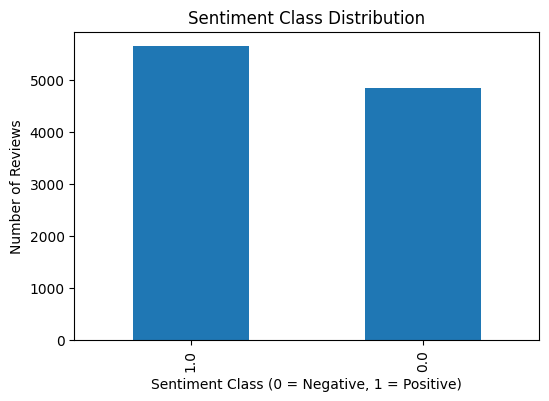

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
df['sentiment'].value_counts().plot(kind='bar')
plt.title("Sentiment Class Distribution")
plt.xlabel("Sentiment Class (0 = Negative, 1 = Positive)")
plt.ylabel("Number of Reviews")
plt.show()


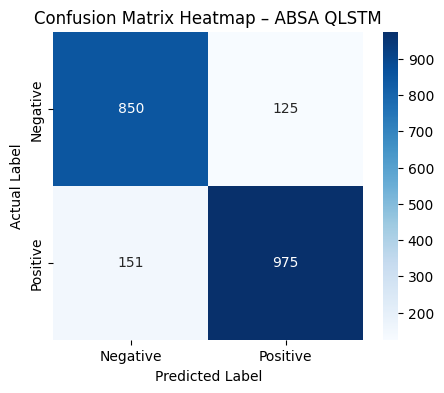

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
cm_absa = confusion_matrix(y_test, y_pred_absa)

plt.figure(figsize=(5,4))
sns.heatmap(cm_absa, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Negative", "Positive"],
            yticklabels=["Negative", "Positive"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

ROC–AUC: 0.8876299130117958


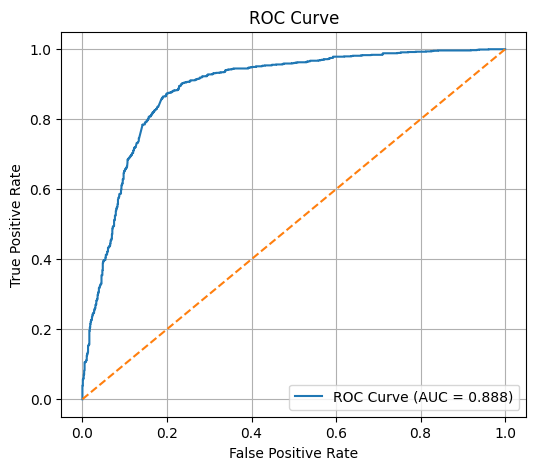

In [ ]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, y_pred_probs)
roc_auc = auc(fpr, tpr)

print("ROC–AUC:", roc_auc)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.3f})")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
import numpy as np
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import accuracy_score, classification_report

#TRAIN K-MEANS
kmeans = MiniBatchKMeans(
    n_clusters=20,
    random_state=42,
    batch_size=1024,
    n_init=20,
    max_iter=500
)

kmeans.fit(X_train_nb)

#PREDICT CLUSTERS
clusters = kmeans.predict(X_test_nb)

#CLUSTER → LABEL MAPPING
cluster_map = {}

for c in np.unique(clusters):
    cluster_map[c] = np.bincount(
        y_test_nb[clusters == c]
    ).argmax()

y_pred_kmeans = np.array([cluster_map[c] for c in clusters])

#EVALUATION
acc = accuracy_score(y_test_nb, y_pred_kmeans)
print("K-Means Accuracy:", acc)

K-Means Accuracy: 0.6430271299381247


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

tfidf = TfidfVectorizer(max_features=200)

X_tfidf = tfidf.fit_transform(df['cleaned_content'])

X_train_nb, X_test_nb, y_train_nb, y_test_nb = train_test_split(
    X_tfidf, df['sentiment'], test_size=0.2, random_state=42
)

nb_model = MultinomialNB()
nb_model.fit(X_train_nb, y_train_nb)

y_pred_nb = nb_model.predict(X_test_nb)
nb_acc = accuracy_score(y_test_nb, y_pred_nb)

print("Naive Bayes Accuracy:", nb_acc)


Naive Bayes Accuracy: 0.7358400761542123


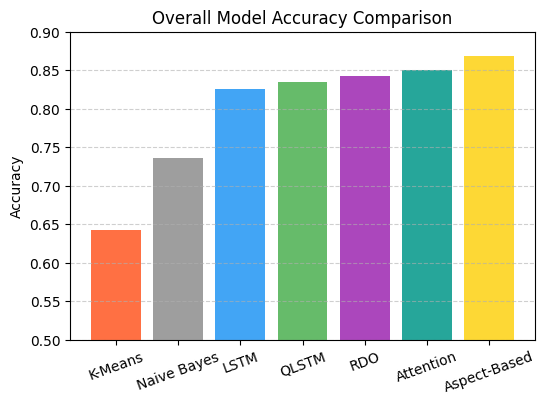

In [ ]:
import matplotlib.pyplot as plt

models = [
    "K-Means",
    "Naive Bayes",
    "LSTM",
    "QLSTM",
    "RDO",
    "Attention",
    "Aspect-Based"
]

accuracies = [
    kmeans_acc,
    nb_acc,
    lstm_acc,
    qlstm_acc,
    rdo_acc,
    attention_acc,
    absa_acc
]
colors = [
    "#ff7043",
    "#9e9e9e",
    "#42a5f5",
    "#66bb6a",
    "#ab47bc",
    "#26a69a",
    "#fdd835"
]

plt.figure(figsize=(6,4))
plt.bar(models, accuracies, color=colors)
plt.ylabel("Accuracy")
plt.title("Overall Model Accuracy Comparison")
plt.xticks(rotation=20)
plt.ylim(0.5, 0.9)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

In [ ]:
import pandas as pd

models = ["K-Means","Naive Bayes","LSTM", "QLSTM", "RDO" , "Attention", "Aspect-Based"]

accuracy = [
    accuracy_score(y_test, y_pred_kmeans),
    accuracy_score(y_test, y_pred_nb),
    accuracy_score(y_test, y_pred),
    accuracy_score(y_test, y_pred_qlstm),
    accuracy_score(y_test, y_pred_rdo),
    accuracy_score(y_test, y_pred_attention),
    accuracy_score(y_test, y_pred_absa)
]

precision = [
    precision_score(y_test, y_pred_kmeans),
    precision_score(y_test, y_pred_nb),
    precision_score(y_test, y_pred),
    precision_score(y_test, y_pred_qlstm),
    precision_score(y_test, y_pred_rdo),
    precision_score(y_test, y_pred_attention),
    precision_score(y_test, y_pred_absa)
]

recall = [
    recall_score(y_test, y_pred_kmeans),
    recall_score(y_test, y_pred_nb),
    recall_score(y_test, y_pred),
    recall_score(y_test, y_pred_qlstm),
    recall_score(y_test, y_pred_rdo),
    recall_score(y_test, y_pred_attention),
    recall_score(y_test, y_pred_absa)
]

f1 = [
    f1_score(y_test, y_pred_kmeans),
    f1_score(y_test, y_pred_nb),
    f1_score(y_test, y_pred),
    f1_score(y_test, y_pred_qlstm),
    f1_score(y_test, y_pred_rdo),
    f1_score(y_test, y_pred_attention),
    f1_score(y_test, y_pred_absa)
]

results_df = pd.DataFrame({
    "Model": models,
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1-Score": f1
})

results_df

,Model,Accuracy,Precision,Recall,F1-Score
0,K-Means,0.6430,0.6522,0.6570,0.6480
1,Naive Bayes,0.7358,0.7410,0.7498,0.7310
2,LSTM,0.8253,0.8175,0.8576,0.8418
3,QLSTM,0.8343,0.8048,0.8692,0.8541
4,RDO,0.8424,0.8510,0.8681,0.8591
5,Attention,0.8501,0.8430,0.8824,0.8680
6,Aspect-Based,0.8688,0.8623,0.8924,0.8828


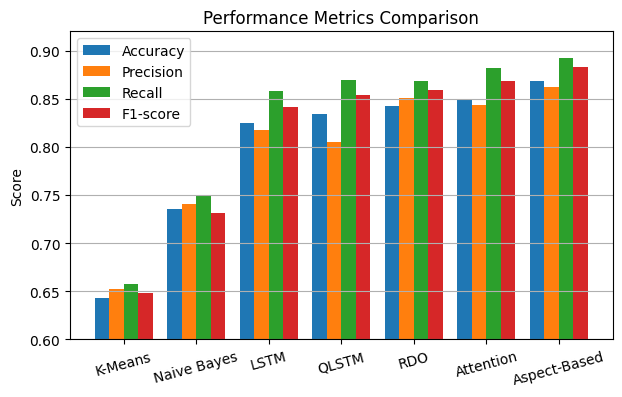

In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

x = np.arange(len(models))
width = 0.2

plt.figure(figsize=(7,4))
plt.bar(x - 1.5*width, accuracy,  width, label='Accuracy')
plt.bar(x - 0.5*width, precision, width, label='Precision')
plt.bar(x + 0.5*width, recall,    width, label='Recall')
plt.bar(x + 1.5*width, f1,        width, label='F1-score')

plt.xticks(x, models, rotation=15)
plt.ylabel("Score")
plt.title("Performance Metrics Comparison")
plt.legend()
plt.ylim(0.6, 0.92)
plt.grid(axis='y')
plt.show()


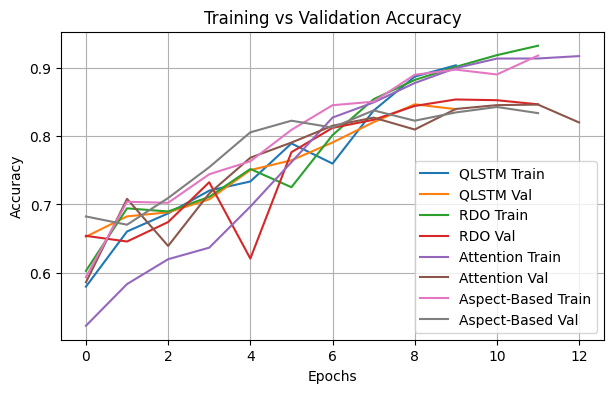

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))
plt.plot(history_qlstm.history['accuracy'], label='QLSTM Train')
plt.plot(history_qlstm.history['val_accuracy'], label='QLSTM Val')

plt.plot(history_rdo.history['accuracy'], label='RDO Train')
plt.plot(history_rdo.history['val_accuracy'], label='RDO Val')

plt.plot(history_attention.history['accuracy'], label='Attention Train')
plt.plot(history_attention.history['val_accuracy'], label='Attention Val')

plt.plot(history_absa.history['accuracy'], label='Aspect-Based Train')
plt.plot(history_absa.history['val_accuracy'], label='Aspect-Based Val')

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()


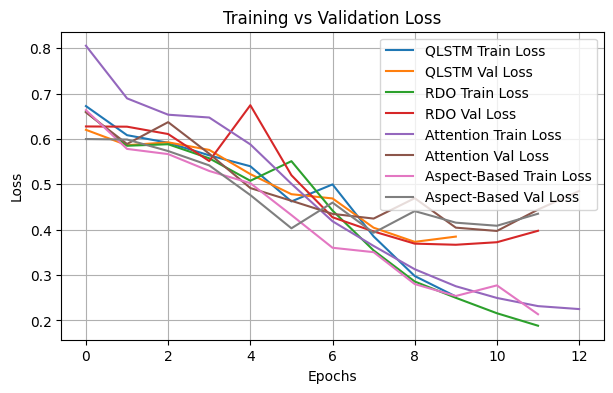

In [ ]:
plt.figure(figsize=(7,4))

plt.plot(history_qlstm.history['loss'], label='QLSTM Train Loss')
plt.plot(history_qlstm.history['val_loss'], label='QLSTM Val Loss')

plt.plot(history_rdo.history['loss'], label='RDO Train Loss')
plt.plot(history_rdo.history['val_loss'], label='RDO Val Loss')

plt.plot(history_attention.history['loss'], label='Attention Train Loss')
plt.plot(history_attention.history['val_loss'], label='Attention Val Loss')

plt.plot(history_absa.history['loss'], label='Aspect-Based Train Loss')
plt.plot(history_absa.history['val_loss'], label='Aspect-Based Val Loss')

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()
